In [41]:
import os
import esigmapy
import numpy as np
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
from astropy.constants import GM_sun, c
from scipy.interpolate import CubicSpline
from gwrompy.utils import find_t_location

In [27]:
m1, m2, spin1z, spin2z = 20, 20, 0, 0
f_low, delta_t = 10, 1/4096
modes_to_use = [(2,2)]

In [28]:
t_norm = GM_sun.value * (20 + 20) / (c.value**3)

In [ ]:
e_vals = np.linspace(0, 0.2, 100)
l_vals = np.linspace(-np.pi, np.pi, 100)
e_grid, l_grid = np.meshgrid(e_vals, l_vals)

harmonics_matrxi_list = []

In [ ]:
time_min = []

def compute_for_pair(e, l):
    orb_vars, _ = esigmapy.get_inspiral_esigma_modes(
        mass1=m1, mass2=m2,
        spin1z=spin1z, spin2z=spin2z,
        eccentricity=e, mean_anomaly=l,
        f_lower=f_low, delta_t=delta_t,
        include_conjugate_modes=False,
        modes_to_use=modes_to_use,
        return_orbital_params=['x', 'l']
    )

    x_data = orb_vars['x']
    times = orb_vars["x"].sample_times / t_norm

    t_ref = find_t_location(times, x_data, 0.1)
    times = times - t_ref

    return times.min()

results = Parallel(n_jobs=16)(
    delayed(compute_for_pair)(e, l)
    for e in e_vals
    for l in l_vals
)

time_min = list(results)

max(time_min)

-50484.226733748226

In [42]:
common_time_grid = np.arange(max(time_min), 0, 1e-2)

In [48]:
l_min = []
l_max = []

def compute_for_pair(e, l):
    orb_vars, _ = esigmapy.get_inspiral_esigma_modes(
        mass1=m1, mass2=m2,
        spin1z=spin1z, spin2z=spin2z,
        eccentricity=e, mean_anomaly=l,
        f_lower=f_low, delta_t=delta_t,
        include_conjugate_modes=False,
        modes_to_use=modes_to_use,
        return_orbital_params=['x', 'l']
    )

    x_data = orb_vars['x']
    l_data = orb_vars['l']
    times = orb_vars["x"].sample_times / t_norm

    t_ref = find_t_location(times, x_data, 0.1)
    times = times - t_ref

    l_spline = CubicSpline(times, l_data)
    l_reco_t = l_spline(common_time_grid)

    return l_reco_t.min(), l_reco_t.max()

results = Parallel(n_jobs=16)(
    delayed(compute_for_pair)(e, l)
    for e in e_vals
    for l in l_vals
)

l_min = [res[0] for res in results]
l_max = [res[1] for res in results]

max(l_min), min(l_max)

(57.94683311758904, 404.0324774138859)

In [49]:
def generate_waveform_in_mean_ano_domain(e, l):
    orb_vars, mode = esigmapy.get_inspiral_esigma_modes(mass1=m1, 
                                            mass2=m2,
                                            spin1z=spin1z, 
                                            spin2z=spin2z,
                                            eccentricity=e,
                                            mean_anomaly=l,
                                            f_lower=f_low,
                                            delta_t=delta_t,
                                            include_conjugate_modes=False,
                                            modes_to_use=modes_to_use,
                                            return_orbital_params=['x', 'l'])
    
    signal = mode[(2,2)]

    x_data = orb_vars['x']
    l_data = orb_vars['l']
    times = orb_vars["x"].sample_times / t_norm

    t_ref = find_t_location(times, x_data, 0.1)
    times -= t_ref

    amp_spline_t = CubicSpline(times, np.abs(signal))
    phase_spline_t = CubicSpline(times, np.unwrap(np.angle(signal)))
    l_spline = CubicSpline(times, l_data)

    amp_reco_t = amp_spline_t(common_time_grid)
    phase_reco_t = phase_spline_t(common_time_grid)
    l_reco_t = l_spline(common_time_grid)

    t_of_l = CubicSpline(l_reco_t, common_time_grid)
    
    l_uniform = np.arange(max(l_min), min(l_max), 1e-2)
    t_uniform_in_l = t_of_l(l_uniform)

    amp_spline_l = CubicSpline(common_time_grid, amp_reco_t)
    phase_spline_l = CubicSpline(common_time_grid, phase_reco_t)

    amp_reco_l = amp_spline_l(t_uniform_in_l)
    phase_reco_l = phase_spline_l(t_uniform_in_l)

    return amp_reco_l * np.exp(1j*phase_reco_l), l_uniform

In [52]:
signal, l_uniform = generate_waveform_in_mean_ano_domain(e_vals[99], l_vals[20])

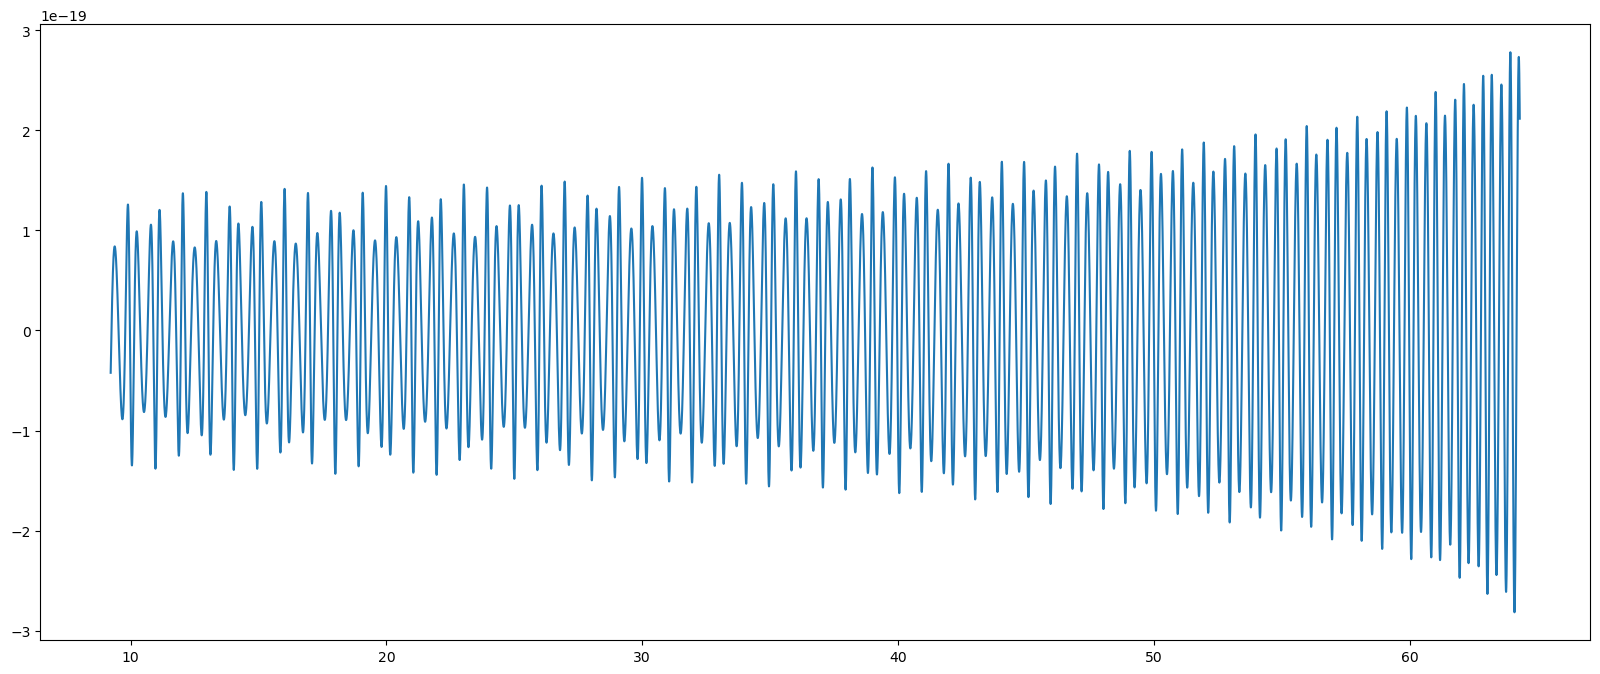

In [53]:
plt.figure(figsize=(20, 8))
plt.plot(l_uniform / (2* np.pi), signal.real)